In [2]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\agsto\Desktop\times-series-anomaly-detection-on-twitter-data\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
path = kagglehub.dataset_download("julienjta/twitter-mentions-volumes")

print(os.listdir(path))

['dataset.csv']


In [4]:
file_path = os.path.join(path, 'dataset.csv')

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

In [5]:
df

,timestamp,Apple,Amazon,Salesforce,CVS,Facebook,Google,IBM,Coca-Cola,Pfizer,UPS
0,2015-02-26 21:42:53,104,57.0,11,0.0,53.0,35.0,7.0,8.0,3.0,2.0
1,2015-02-26 21:47:53,100,43.0,10,0.0,64.0,41.0,4.0,8.0,2.0,2.0
2,2015-02-26 21:52:53,99,55.0,3,0.0,49.0,32.0,14.0,5.0,2.0,4.0
3,2015-02-26 21:57:53,154,64.0,4,0.0,48.0,36.0,6.0,13.0,36.0,3.0
4,2015-02-26 22:02:53,120,93.0,9,0.0,22.0,32.0,1.0,22.0,8.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...
15897,2015-04-23 02:27:53,44,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15898,2015-04-23 02:32:53,45,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15899,2015-04-23 02:37:53,48,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15900,2015-04-23 02:42:53,26,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [7]:
df = df.dropna() #we have so plenty of data we could just drop or use only apple and salesforce

In [8]:
df = df.set_index('timestamp')

In [9]:
n = len(df)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

print(n, train_end, val_end)

15831 11081 13456


In [10]:
train = df.iloc[:train_end]
val = df.iloc[train_end:val_end]
test = df.iloc[val_end:]

In [11]:
train

,Apple,Amazon,Salesforce,CVS,Facebook,Google,IBM,Coca-Cola,Pfizer,UPS
timestamp,,,,,,,,,,
2015-02-26 21:42:53,104,57.0,11,0.0,53.0,35.0,7.0,8.0,3.0,2.0
2015-02-26 21:47:53,100,43.0,10,0.0,64.0,41.0,4.0,8.0,2.0,2.0
2015-02-26 21:52:53,99,55.0,3,0.0,49.0,32.0,14.0,5.0,2.0,4.0
2015-02-26 21:57:53,154,64.0,4,0.0,48.0,36.0,6.0,13.0,36.0,3.0
2015-02-26 22:02:53,120,93.0,9,0.0,22.0,32.0,1.0,22.0,8.0,5.0
...,...,...,...,...,...,...,...,...,...,...
2015-04-06 08:42:53,14,36.0,3,0.0,7.0,15.0,0.0,4.0,1.0,1.0
2015-04-06 08:47:53,13,40.0,0,0.0,16.0,3.0,2.0,5.0,0.0,1.0
2015-04-06 08:52:53,19,27.0,1,0.0,9.0,8.0,0.0,5.0,0.0,1.0


In [12]:
from sklearn.preprocessing import StandardScaler

def scale_data(df):
    df = np.log1p(df)

    window_size = 12
    df_detrended = df - df.rolling(window_size).mean()
    df_detrended = df_detrended.dropna()

    scaled = StandardScaler().fit_transform(df)

    scaled_df = pd.DataFrame(
    scaled,
    columns=df.columns,
    index=df.index
    )

    return df_detrended

In [13]:
train_scaled = scale_data(train)
train_scaled

,Apple,Amazon,Salesforce,CVS,Facebook,Google,IBM,Coca-Cola,Pfizer,UPS
timestamp,,,,,,,,,,
2015-02-26 22:37:53,0.136774,-0.107436,0.053109,-0.115525,-0.010621,-0.124834,-0.132332,-0.008461,-0.603973,0.072862
2015-02-26 22:42:53,0.315001,0.049193,0.098025,0.519860,0.417407,-0.010590,-0.121205,0.426253,-0.546211,-0.586497
2015-02-26 22:47:53,0.553192,0.077335,-0.640999,-0.173287,0.240226,0.043820,0.344836,-0.266894,-0.512422,0.454353
2015-02-26 22:52:53,0.123119,0.058999,-0.617025,-0.173287,0.087627,0.227724,0.099723,-0.408651,-0.478634,0.272032
2015-02-26 22:57:53,-0.044751,-0.005763,0.529185,-0.173287,0.214862,0.149965,0.483793,0.009660,-0.235486,0.561869
...,...,...,...,...,...,...,...,...,...,...
2015-04-06 08:42:53,-0.385240,-0.482146,0.765068,0.000000,-0.229545,0.196174,-0.783386,-0.082266,0.519860,0.288811
2015-04-06 08:47:53,-0.405915,-0.408349,-0.529676,0.000000,0.422246,-1.098570,0.315226,0.124029,-0.115525,0.288811
2015-04-06 08:52:53,-0.045174,-0.759993,0.163472,0.000000,-0.086519,-0.308582,-0.783386,0.148002,-0.115525,0.288811


In [14]:
val_scaled = scale_data(val)
val_scaled

,Apple,Amazon,Salesforce,CVS,Facebook,Google,IBM,Coca-Cola,Pfizer,UPS
timestamp,,,,,,,,,,
2015-04-06 10:02:53,0.410360,0.014382,0.683332,-0.173287,0.043686,-0.336157,2.705548,0.092492,-0.149313,-0.481729
2015-04-06 10:07:53,0.016978,-0.209442,0.772356,-0.173287,-1.052013,-0.059602,0.378425,0.605473,-0.149313,-0.423966
2015-04-06 10:12:53,-0.266083,-0.354645,0.805364,-0.173287,0.012810,-0.313495,0.074961,0.250406,-0.149313,-0.423966
2015-04-06 10:17:53,-0.085508,-0.370730,0.078428,-0.173287,0.109391,-0.262984,1.208134,0.417534,-0.149313,0.302970
2015-04-06 10:22:53,0.176856,0.064938,0.512896,-0.173287,0.090795,0.159204,-0.829328,0.995157,0.486072,-0.390178
...,...,...,...,...,...,...,...,...,...,...
2015-04-14 14:37:53,0.808194,-0.404051,0.688530,-0.173287,-0.006862,0.537620,0.394918,0.004590,-0.619250,-0.527699
2015-04-14 14:42:53,0.217071,-0.332142,0.303816,0.949299,-0.464080,0.431174,0.816921,0.021893,-0.485130,-0.098261
2015-04-14 14:47:53,-0.019858,-0.163354,0.115877,-0.149313,0.109857,-0.183742,0.261179,2.459202,-0.055692,-1.047560


In [15]:
test_scaled = scale_data(test)
test_scaled

,Apple,Amazon,Salesforce,CVS,Facebook,Google,IBM,Coca-Cola,Pfizer,UPS
timestamp,,,,,,,,,,
2015-04-14 15:57:53,0.273919,0.063528,0.652060,-0.438125,0.318791,0.086870,0.445777,0.352074,-1.383006,-0.037097
2015-04-14 16:02:53,-0.088767,0.016406,0.468112,-0.438125,-0.244897,-0.251203,0.288755,0.153278,-0.284393,-0.986396
2015-04-14 16:07:53,-0.000247,-0.000897,0.047453,-0.438125,-0.168464,-0.269663,0.572188,-0.377350,0.003289,-0.870871
2015-04-14 16:12:53,0.150916,-0.099438,-0.381985,-0.380362,-0.346883,-0.097200,-0.266272,-0.452067,-1.248886,-0.235486
2015-04-14 16:17:53,0.132981,-0.204611,-0.611905,-0.380362,0.351746,-0.139874,-0.520165,0.031136,-0.479381,0.912880
...,...,...,...,...,...,...,...,...,...,...
2015-04-22 20:32:53,-0.533427,-0.085566,0.083078,-0.231049,0.005345,-0.094821,-0.848149,-0.338815,-0.947229,0.232865
2015-04-22 20:37:53,-0.407659,-0.019493,0.231611,-0.231049,-0.141360,-0.074948,0.235269,0.182561,0.117595,-0.048041
2015-04-22 20:42:53,-0.684757,-0.157730,-0.628665,-0.231049,-0.347833,0.031959,1.076601,-0.122582,-0.831704,-0.335723


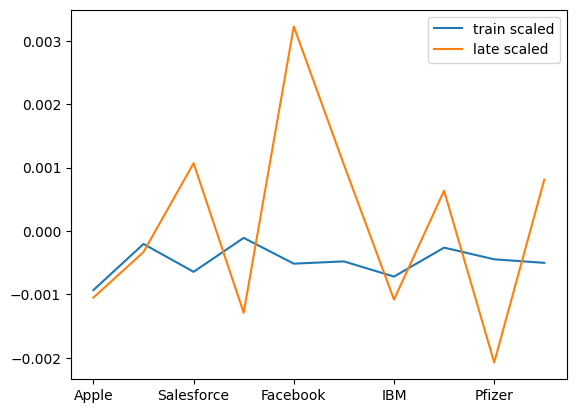

In [16]:
import matplotlib.pyplot as plt

train_scaled.mean().plot(label="train scaled")
test_scaled.mean().plot(label="late scaled")
plt.legend()

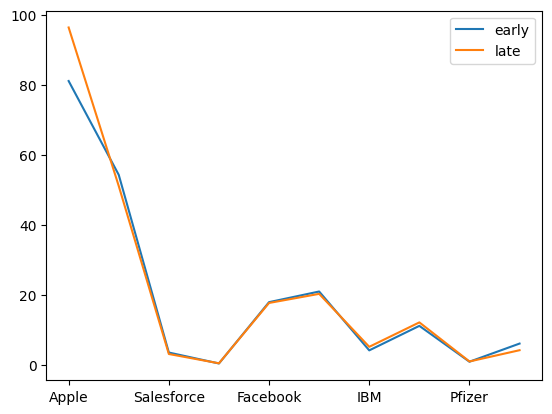

In [17]:
df.iloc[:train_end].mean().plot(label="early")
df.iloc[train_end:].mean().plot(label="late")
plt.legend()

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [19]:
def create_dataset(X, time_steps=12):
    Xs = []
    for i in range(len(X) - time_steps + 1):
        v = X.iloc[i:(i + time_steps)].values
        Xs.append(v)
    return np.array(Xs)

In [20]:
timestep = 12 #3 or above seems to do better

#can change this value for amounts in window so the int * 5 is how many minutes is in the window
#a lower value make it less aggresive in determining if anomaly, higher also makes it reconstruct poorly

X_train = create_dataset(train, time_steps=timestep)
X_val = create_dataset(val, time_steps=timestep)
X_test = create_dataset(test, time_steps=timestep)

In [21]:
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_tensor),
    batch_size=64,
    shuffle=False
)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)

val_loader = DataLoader(
    TensorDataset(X_val_tensor),
    batch_size=64,
    shuffle=False
)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

test_loader = DataLoader(
    TensorDataset(X_test_tensor),
    batch_size=64,
    shuffle=False
)

## Experimental LSTM autoencoder (no vae)

## This performs better at reconstruction

In [22]:
import torch
import torch.nn as nn


class Encoder(nn.Module):

    def __init__(self, n_features, hidden_dim, latent_dim):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):

        _, (hidden, _) = self.lstm(x)

        hidden = hidden[-1]

        latent = self.fc(hidden)

        return latent


class Decoder(nn.Module):

    def __init__(self, latent_dim, hidden_dim, seq_len, n_features):

        super().__init__()

        self.seq_len = seq_len
        self.hidden_dim = hidden_dim

        self.fc = nn.Linear(latent_dim, hidden_dim)

        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.output_layer = nn.Sequential( #to get rid of negative values
            nn.Linear(hidden_dim, n_features),
            nn.Softplus()
            )

    def forward(self, z):

        hidden = self.fc(z)

        repeated = hidden.unsqueeze(1).repeat(1, self.seq_len, 1)

        decoded, _ = self.lstm(repeated)

        reconstruction = self.output_layer(decoded)

        return reconstruction


class LSTMAutoencoder(nn.Module):

    def __init__(
        self,
        n_features,
        seq_len,
        hidden_dim=64,
        latent_dim=8
    ):

        super().__init__()

        self.encoder = Encoder(
            n_features,
            hidden_dim,
            latent_dim
        )

        self.decoder = Decoder(
            latent_dim,
            hidden_dim,
            seq_len,
            n_features
        )

    def forward(self, x):

        z = self.encoder(x)

        reconstruction = self.decoder(z)

        return reconstruction

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMAutoencoder(
    n_features=X_train.shape[2],
    seq_len=X_train.shape[1],
    hidden_dim=32,
    latent_dim=4
).to(device)

In [24]:
criterion = nn.MSELoss()

In [25]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses = []
val_losses = []

best_val = float("inf")

for epoch in range(300): #how many epochs


    model.train()

    train_total = 0

    for (x,) in train_loader:

        x = x.to(device)

        optimizer.zero_grad()

        reconstruction = model(x)

        loss = criterion(reconstruction, x)

        loss.backward()

        optimizer.step()

        train_total += loss.item()

    avg_train = train_total / len(train_loader)


    model.eval()

    val_total = 0

    with torch.no_grad():

        for (x,) in val_loader:

            x = x.to(device)

            reconstruction = model(x)

            loss = criterion(reconstruction, x)

            val_total += loss.item()

    avg_val = val_total / len(val_loader)

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    # save best model
    if avg_val < best_val:

        best_val = avg_val

        torch.save(
            model.state_dict(),
            "best_lstm_autoencoder.pt"
        )

    print(
        f"Epoch {epoch}: "
        f"train={avg_train:.4f}, "
        f"val={avg_val:.4f}"
    )

Epoch 0: train=9210.8959, val=2565.5803
Epoch 1: train=9047.3529, val=2457.0315
Epoch 2: train=8942.9201, val=2375.4776
Epoch 3: train=8860.3839, val=2309.7283
Epoch 4: train=8792.0414, val=2255.1231
Epoch 5: train=8734.2696, val=2209.0545
Epoch 6: train=8684.8007, val=2169.8529
Epoch 7: train=8642.0972, val=2136.3407
Epoch 8: train=8605.0730, val=2107.6186
Epoch 9: train=8572.8434, val=2082.9507
Epoch 10: train=8544.6712, val=2061.7112
Epoch 11: train=8519.9825, val=2043.3818
Epoch 12: train=8498.2105, val=2027.4555
Epoch 13: train=8478.9103, val=2013.5986
Epoch 14: train=8461.7037, val=2001.4681
Epoch 15: train=8446.3285, val=1990.8024
Epoch 16: train=8432.4920, val=1981.3572
Epoch 17: train=8420.0722, val=1973.0247
Epoch 18: train=8399.4010, val=1937.6542
Epoch 19: train=8364.5723, val=1919.6865
Epoch 20: train=8343.4445, val=1907.0991
Epoch 21: train=8326.5314, val=1895.1147
Epoch 22: train=8309.9355, val=1884.5101
Epoch 23: train=8294.1716, val=1874.6580
Epoch 24: train=8280.1344,

In [26]:
model.load_state_dict(
    torch.load("best_lstm_autoencoder.pt")
)

model.eval()

C:\Users\agsto\AppData\Local\Temp\ipykernel_28412\3627818868.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("best_lstm_autoencoder.pt")


LSTMAutoencoder(
  (encoder): Encoder(
    (lstm): LSTM(10, 32, batch_first=True)
    (fc): Linear(in_features=32, out_features=4, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=4, out_features=32, bias=True)
    (lstm): LSTM(32, 32, batch_first=True)
    (output_layer): Sequential(
      (0): Linear(in_features=32, out_features=10, bias=True)
      (1): Softplus(beta=1.0, threshold=20.0)
    )
  )
)

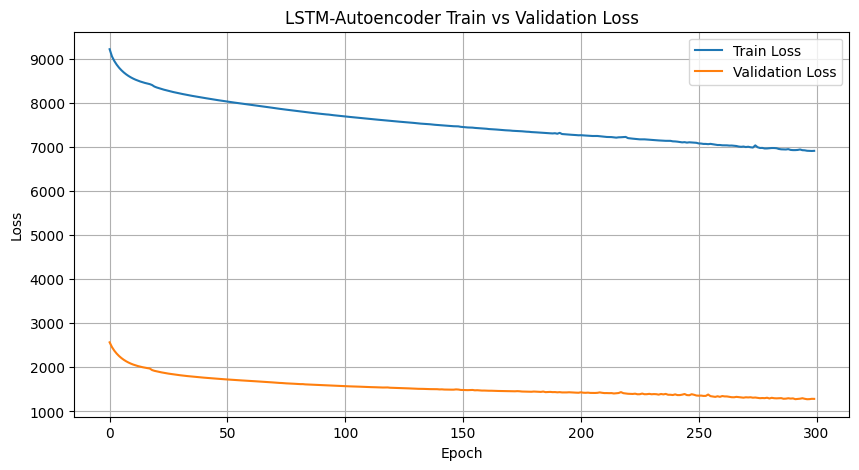

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM-Autoencoder Train vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [28]:
all_x = []
all_recon = []

with torch.no_grad():

    for (x,) in val_loader:

        x = x.to(device)

        reconstruction = model(x)

        all_x.append(x.cpu())
        all_recon.append(reconstruction.cpu())

x_test = torch.cat(all_x, dim=0)
x_recon = torch.cat(all_recon, dim=0)

In [29]:
x_recon.shape

torch.Size([2364, 12, 10])

In [30]:
all_x = []
all_recon = []

with torch.no_grad():

    for (x,) in test_loader:

        x = x.to(device)

        reconstruction = model(x)

        all_x.append(x.cpu())
        all_recon.append(reconstruction.cpu())

x_test = torch.cat(all_x, dim=0)
x_recon = torch.cat(all_recon, dim=0)

## Company 

In [143]:
company_idx = 4 #change this to see different companies

company_name = test.columns[company_idx]

In [144]:
actual = x_test[:, :, company_idx].numpy()
reconstructed = x_recon[:, :, company_idx].numpy()

actual_flat = actual[:, -1]
reconstructed_flat = reconstructed[:, -1]

error = (actual_flat - reconstructed_flat) ** 2

### IQR anomaly

In [158]:
Q1 = np.percentile(error, 25)
Q3 = np.percentile(error, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

threshold = upper_bound

anomalies = error > threshold

print(threshold)

threshold = np.full(actual.shape[0], threshold)

158.19879


### percentile anomaly

In [52]:
threshold = np.percentile(error, 99)

anomalies = error > threshold

threshold

np.float32(2330.6323)

# Median Threshold

In [193]:
median = np.median(error)

mad = np.median(np.abs(error - median)) 

threshold = median + 10 * mad

anomalies = error > threshold

threshold

print(threshold)


threshold = np.full(actual.shape[0], threshold)

210.79973


## SD anomaly

In [188]:
threshold = error.mean() + 1 * error.std() #change int for how aggresive the threshold is

anomalies = error > threshold

threshold

print(threshold)


threshold = np.full(actual.shape[0], threshold)


2602.6611


# Window Based

In [180]:
errors = pd.Series(error)

window = 36

global_mean = errors.mean()
global_std = errors.std()
k = 2


rolling_mean = errors.rolling(window).mean()

rolling_std = errors.rolling(window).std()

threshold = rolling_mean + k * rolling_std

threshold = threshold.fillna(global_mean + k * global_std)

anomalies = errors > threshold

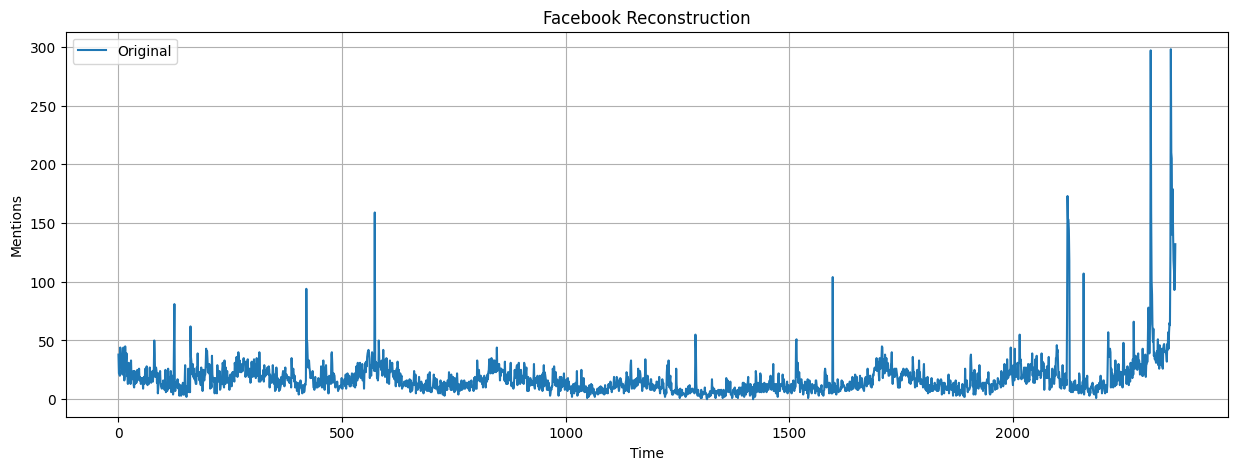

In [172]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15,5))

plt.plot(actual_flat, label="Original")


plt.title(f"{company_name} Reconstruction")

plt.xlabel("Time")
plt.ylabel("Mentions")

plt.legend()

plt.grid(True)

plt.show()

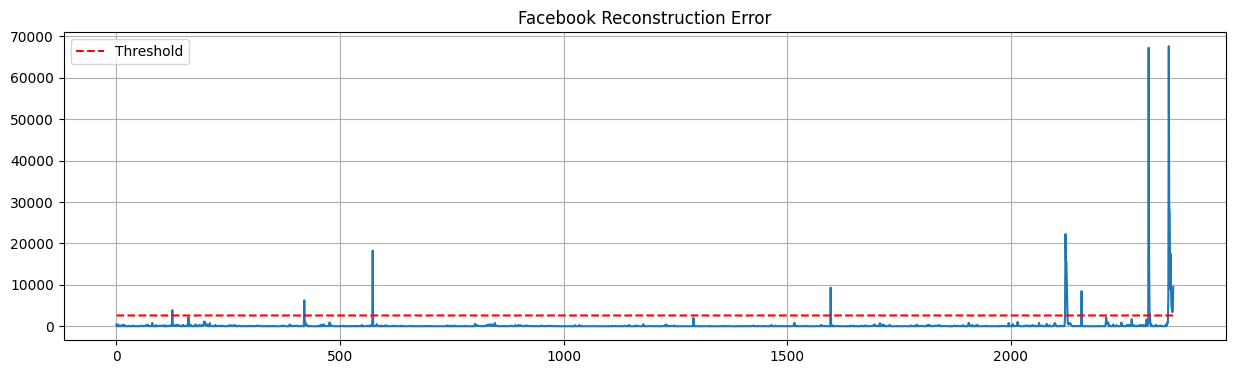

In [189]:
plt.figure(figsize=(15,4))

plt.plot(error)

plt.plot(threshold, linestyle='--', label='Threshold', color='r')

plt.title(f"{company_name} Reconstruction Error")

plt.legend()

plt.grid(True)

plt.show()

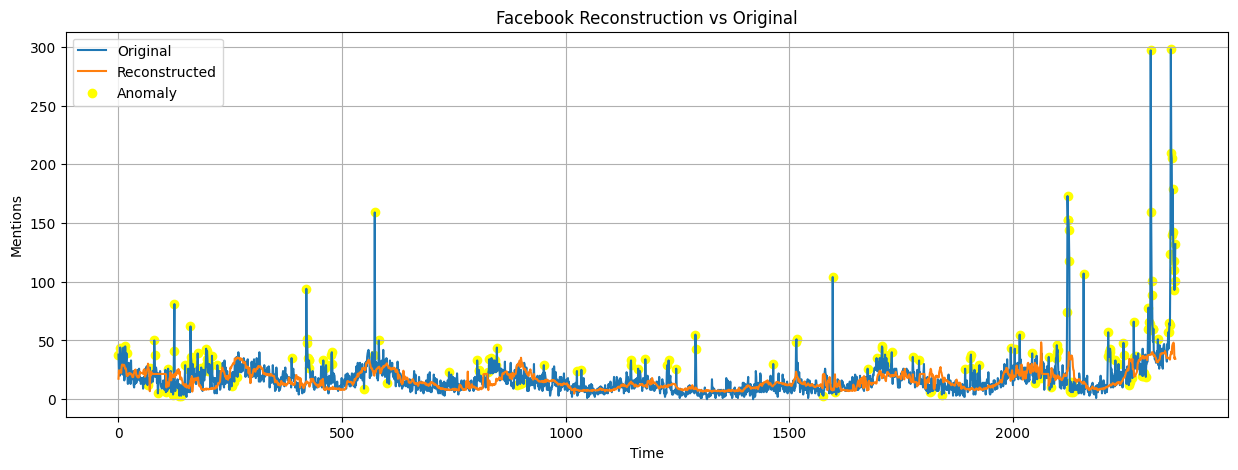

In [194]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15,5))

plt.plot(actual_flat, label="Original")

plt.plot(
    reconstructed_flat,
    label="Reconstructed"
)

plt.scatter(
    np.where(anomalies)[0],
    actual_flat[anomalies],
    marker='o',
    label='Anomaly',
    color='yellow'
)

plt.title(f"{company_name} Reconstruction vs Original")

plt.xlabel("Time")
plt.ylabel("Mentions")

plt.legend()

plt.grid(True)

plt.show()

In [195]:
np.sum(anomalies)

np.int64(196)

In [196]:
np.mean(anomalies)

np.float64(0.0829103214890017)

## Evaluation

In [88]:
def inject_synthetic_anomalies(df, anomaly_portion=0.02, k=5, window=288, random_state=42):
    np.random.seed(random_state)

    df_anom = df.copy()

    # Create anomaly label column
    labels = np.zeros(len(df_anom), dtype=int)

    n_anomalies = int(len(df_anom) * anomaly_portion)

    anomaly_indices = np.random.choice(df_anom.index, size=n_anomalies, replace=False)

    for idx in anomaly_indices:

        row_loc = df_anom.index.get_loc(idx)

        # Modify every column in the row
        for col in df_anom.columns:

            start = max(0, row_loc - window)
            baseline_window = df_anom.iloc[start:row_loc][col]

            # Skip if insufficient history
            if len(baseline_window) < 12:
                continue

            mean = baseline_window.mean()
            sd = baseline_window.std()

            # Inject anomaly
            df_anom.loc[idx, col] = int(round(mean + k * sd))

        labels[row_loc] = 1

    df_anom["anomaly"] = labels

    return df_anom

In [89]:
test_anom = inject_synthetic_anomalies(test, anomaly_portion=.02, k=4)

In [90]:
test_anom = test_anom.astype(int)

In [91]:
def create_window_labels_end(y, time_steps):
    return np.array([
        y[i + time_steps - 1]
        for i in range(len(y) - time_steps + 1)
    ])

In [92]:
X_eval = test_anom.drop(columns=["anomaly"])
y_eval = test_anom["anomaly"].values

In [93]:
X_anom_test = create_dataset(X_eval, time_steps=timestep)

X_test_anom_tensor = torch.tensor(X_anom_test, dtype=torch.float32)

test_anom_loader = DataLoader(
    TensorDataset(X_test_anom_tensor),
    batch_size=64,
    shuffle=False
)

In [94]:
X_anom_test.shape

(2364, 12, 10)

In [95]:
y_window_label = create_window_labels_end(y_eval, time_steps=12)

In [96]:
all_x = []
all_recon = []

with torch.no_grad():

    for (x,) in test_anom_loader:

        x = x.to(device)

        reconstruction = model(x)

        all_x.append(x.cpu())
        all_recon.append(reconstruction.cpu())

x_test_anom = torch.cat(all_x, dim=0)
x_recon_anom = torch.cat(all_recon, dim=0)

# Company

In [221]:
company_idx = 4 #change this to see different companies

company_name = test.columns[company_idx]

In [222]:
actual = x_test_anom[:, :, company_idx].numpy()
reconstructed = x_recon_anom[:, :, company_idx].numpy()

In [223]:
actual_flat = actual[:, -1]
reconstructed_flat = reconstructed[:, -1]

error = (actual_flat - reconstructed_flat) ** 2

In [224]:
Q1 = np.percentile(error, 25)
Q3 = np.percentile(error, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

threshold = upper_bound

anomalies = error > threshold

print(threshold)

threshold = np.full(actual.shape[0], threshold)

173.74255


In [225]:
errors = pd.Series(error)

window = 36

global_mean = errors.mean()
global_std = errors.std()
k = 2

rolling_mean = errors.rolling(window).mean()

rolling_std = errors.rolling(window).std()

threshold = rolling_mean + k * rolling_std

threshold = threshold.fillna(global_mean + k * global_std)

anomalies = errors > threshold

In [226]:
injected_idx = np.where(y_window_label == 1)[0]

tp = np.sum(anomalies[injected_idx])
fn = np.sum(~anomalies[injected_idx])

recall = tp / (tp + fn)

print(f"TP: {tp}")
print(f"FN: {fn}")
print(f"Recall: {recall:.3f}")

TP: 42
FN: 5
Recall: 0.894


In [227]:
y_window_label

array([0, 0, 0, ..., 0, 0, 0], shape=(2364,))

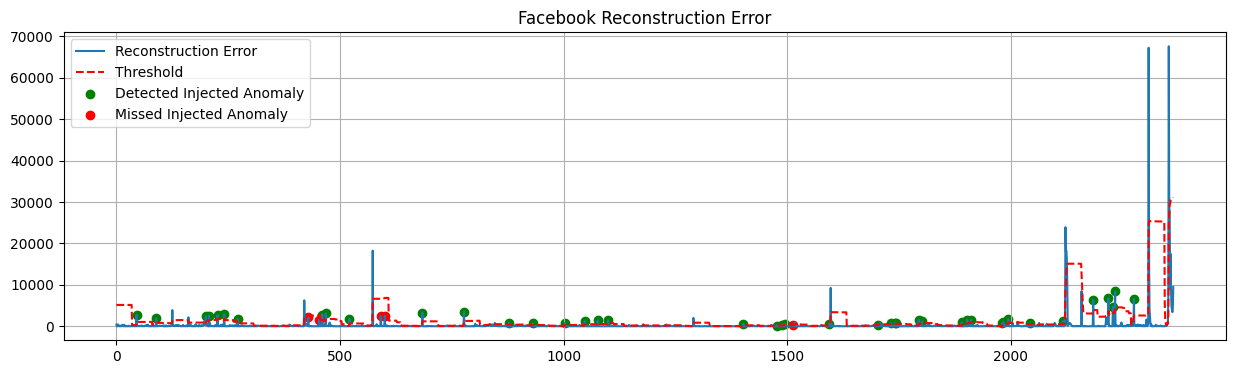

In [228]:
plt.figure(figsize=(15,4))

plt.plot(error, label='Reconstruction Error')
plt.plot(threshold, linestyle='--', label='Threshold', color='r')

# anomaly locations
anomaly_idx = np.where(y_window_label == 1)[0]

# split anomalies by whether they exceed threshold
detected_idx = anomaly_idx[error[anomaly_idx] > threshold[anomaly_idx]]
missed_idx = anomaly_idx[error[anomaly_idx] <= threshold[anomaly_idx]]

plt.scatter(
    detected_idx,
    error[detected_idx],
    color='green',
    marker='o',
    label='Detected Injected Anomaly'
)

plt.scatter(
    missed_idx,
    error[missed_idx],
    color='red',
    marker='o',
    label='Missed Injected Anomaly'
)

plt.title(f"{company_name} Reconstruction Error")
plt.legend()
plt.grid(True)

plt.show()

# Green True Positives
# Red False Negatives

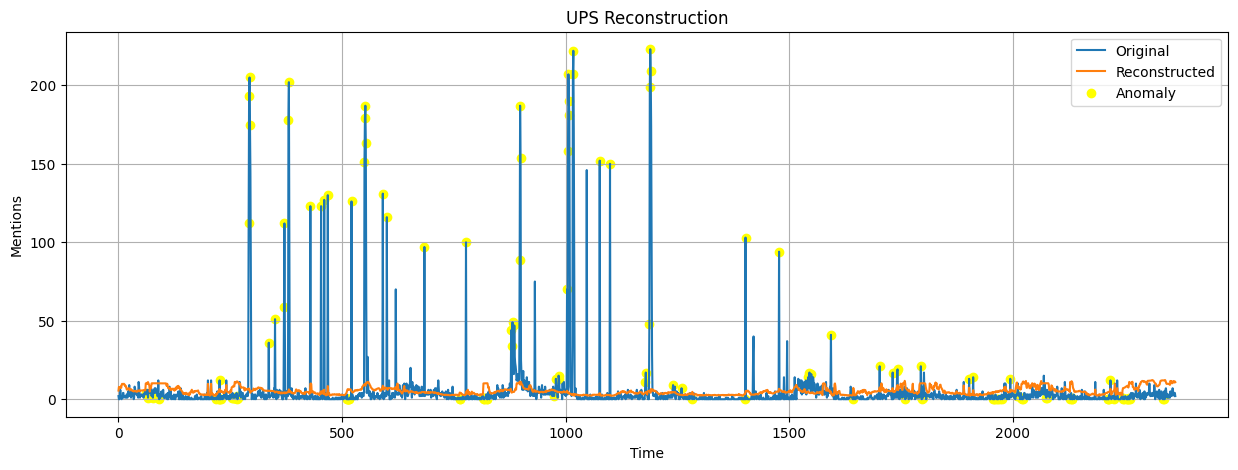

In [121]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15,5))

plt.plot(actual_flat, label="Original")

plt.plot(
    reconstructed_flat,
    label="Reconstructed"
)

plt.scatter(
    np.where(anomalies)[0],
    actual_flat[anomalies],
    marker='o',
    label='Anomaly',
    color='yellow'
)

plt.title(f"{company_name} Reconstruction")

plt.xlabel("Time")
plt.ylabel("Mentions")

plt.legend()

plt.grid(True)

plt.show()

In [203]:
recalls = []

for company_idx in range(len(test.columns)):

    company_name = test.columns[company_idx]

    actual = x_test_anom[:, :, company_idx].numpy()
    reconstructed = x_recon_anom[:, :, company_idx].numpy()

    actual_flat = actual[:, -1]
    reconstructed_flat = reconstructed[:, -1]

    error = (actual_flat - reconstructed_flat) ** 2

    errors = pd.Series(error)

    window = 36
    k = 2

    global_mean = errors.mean()
    global_std = errors.std()

    rolling_mean = errors.rolling(window).mean()
    rolling_std = errors.rolling(window).std()

    threshold = rolling_mean + k * rolling_std
    threshold = threshold.fillna(global_mean + k * global_std)

    anomalies = (errors > threshold).values

    injected_idx = np.where(y_window_label == 1)[0]

    tp = np.sum(anomalies[injected_idx])
    fn = np.sum(~anomalies[injected_idx])

    recall = tp / (tp + fn) 

    recalls.append(recall)

    print(
        f"{company_name} "
        f"Recall={recall:.3f} "
        f"TP={tp} "
        f"FN={fn}"
    )

avg_recall = np.nanmean(recalls)

print("\nAverage Recall Across Companies")
print(f"{avg_recall:.3f}")

Apple Recall=0.851 TP=40 FN=7
Amazon Recall=0.957 TP=45 FN=2
Salesforce Recall=0.745 TP=35 FN=12
CVS Recall=0.872 TP=41 FN=6
Facebook Recall=0.894 TP=42 FN=5
Google Recall=0.766 TP=36 FN=11
IBM Recall=0.766 TP=36 FN=11
Coca-Cola Recall=0.894 TP=42 FN=5
Pfizer Recall=0.851 TP=40 FN=7
UPS Recall=0.553 TP=26 FN=21

Average Recall Across Companies
0.815
